In [5]:
import os
import glob

import numpy as np
import pandas as pd
import xarray as xr

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from scipy.stats import pearsonr

#Main Directory

main_dir = "/data/keeling/a/tahsina2/Alam_et_al_2026" #Update with your own 
clim_dir = "/data/keeling/a/tahsina2/d" #Update with your own which contains the climate forcing data

DATA_DIR = f"{main_dir}/data"
PLOT_DIR = f"{main_dir}/plots"
TABLE_DIR = f"{main_dir}/tables"
CAL_DIR = f"{main_dir}/data/Calibration/AllStations"

### Time Series (Fig 3.2)

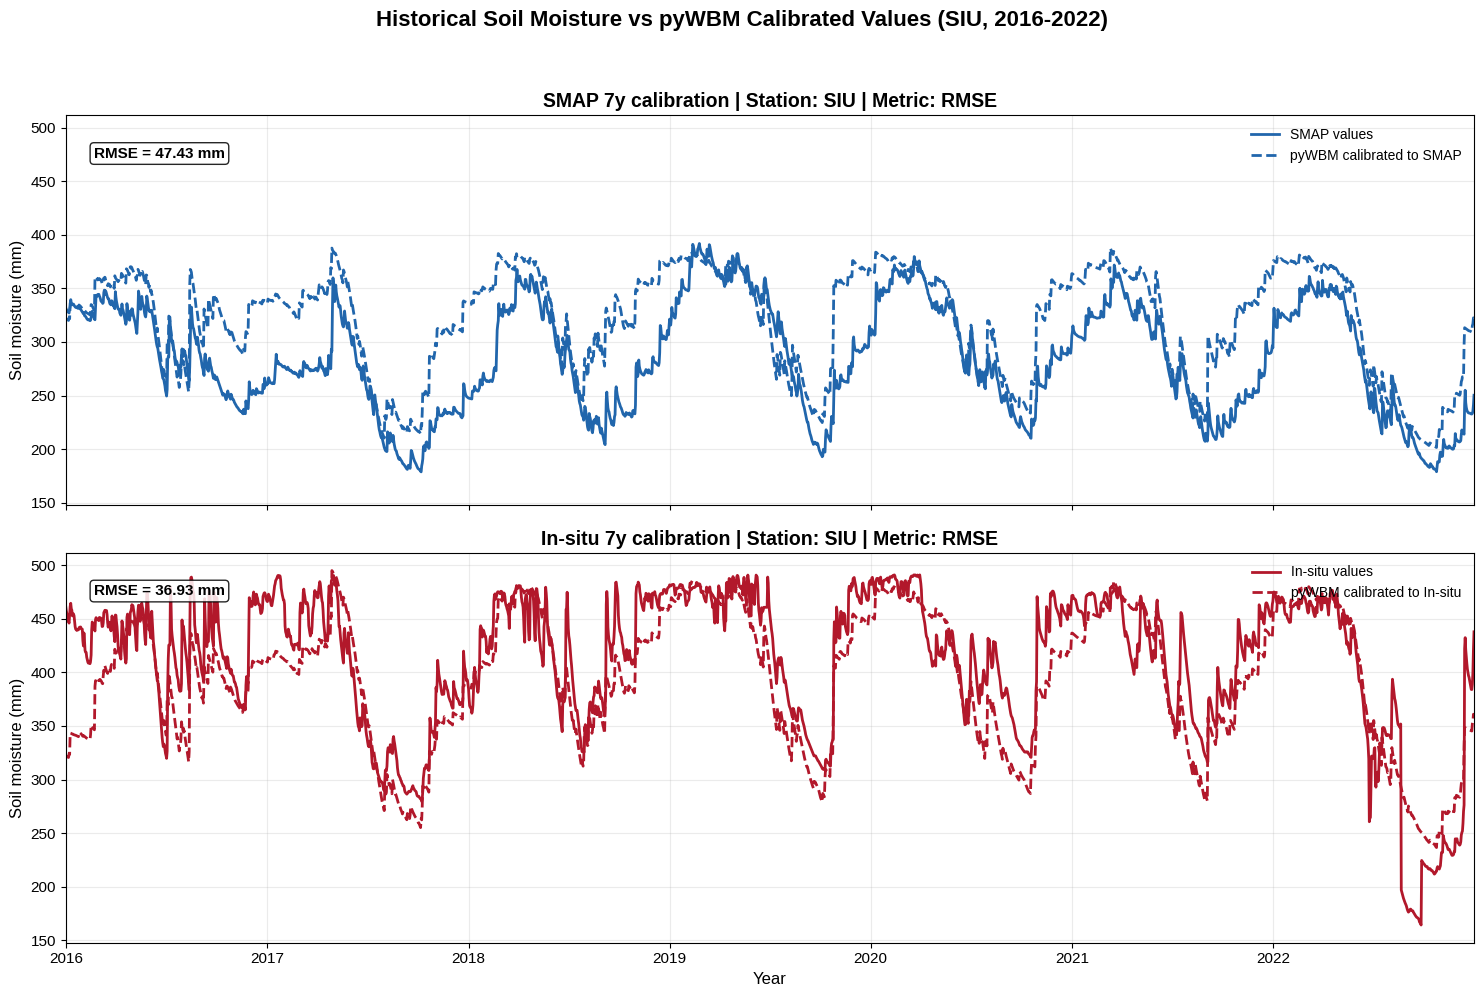

In [6]:
#!/usr/bin/env python3

# ============================================================
# PATHS
# ============================================================

os.makedirs(PLOT_DIR, exist_ok=True)

METRIC_OUTDIRS = {
    "kge":         f"{CAL_DIR}/calibration_outputs_kge_gridmet",
    "kgeprime":    f"{CAL_DIR}/calibration_outputs_kgeprime_gridmet",
    "rmse":        f"{CAL_DIR}/calibration_outputs_rmse_gridmet",
    "outer50rmse": f"{CAL_DIR}/calibration_outputs_outer50rmse_gridmet",
}

# ============================================================
# USER SETTINGS
# ============================================================
REP_STATION = "SIU"
PLOT_METRIC = "rmse"

plot_groups = ["smap_raw", "ins7"]

PLOT_GROUP_LABELS = {
    "smap_raw": "SMAP 7y",
    "ins7": "In-situ 7y",
    "ins20": "In-situ 19y",
}

SOURCE_LABELS = {
    "smap_raw": "SMAP",
    "ins7": "In-situ",
    "ins20": "In-situ",
}

COLORS = {
    "smap_raw": "#2166AC",   # blue
    "ins7": "#B2182B",       # red
    "ins20": "#B2182B",      # same red
}

START_DATE = "2016-01-01"
END_DATE = "2022-12-31"

# ============================================================
# HELPERS
# ============================================================
def scenario_group(attrs):
    src = str(attrs.get("data_source", "")).strip().lower()
    startdate = str(attrs.get("startdate", "")).strip()

    try:
        use_bc = int(attrs.get("use_bias_corrected", 0))
    except Exception:
        use_bc = 0

    if src == "insitu":
        if startdate == "2016-01-01":
            return "ins7"
        return "ins20"

    if src in ["smap", "vic", "mosaic", "noah"]:
        return f"{src}_{'bc' if use_bc == 1 else 'raw'}"

    return None


def time_to_pandas(time_values):
    """
    Safely convert numpy datetime64 or cftime.DatetimeNoLeap to pandas DatetimeIndex.
    """
    out = []

    for tt in time_values:
        if hasattr(tt, "year") and hasattr(tt, "month") and hasattr(tt, "day"):
            out.append(pd.Timestamp(tt.year, tt.month, tt.day))
        else:
            out.append(pd.Timestamp(tt))

    return pd.DatetimeIndex(out)

def calc_rmse(pred, obs):
    pred = np.asarray(pred, dtype=float)
    obs = np.asarray(obs, dtype=float)

    mask = np.isfinite(pred) & np.isfinite(obs)

    if mask.sum() == 0:
        return np.nan

    return np.sqrt(np.mean((pred[mask] - obs[mask]) ** 2))


# ============================================================
# LOAD TARGET AND pyWBM VALUES
# ============================================================
rows = []

out_dir = METRIC_OUTDIRS[PLOT_METRIC]
files = sorted(glob.glob(os.path.join(out_dir, "scenario_*.nc")))

#print(f"{PLOT_METRIC}: found {len(files)} files")

for f in files:
    ds = None

    try:
        ds = xr.open_dataset(f)

        grp = scenario_group(ds.attrs)

        if grp not in plot_groups:
            continue

        station = str(ds.attrs.get("station", "")).strip()

        if station != REP_STATION:
            continue

        if "target_sm" not in ds or "pred_sm_best" not in ds:
            continue

        rows.append({
            "metric": PLOT_METRIC,
            "station": station,
            "group": grp,
            "obs": np.asarray(ds["target_sm"].values, dtype=float),
            "pred": np.asarray(ds["pred_sm_best"].values, dtype=float),
            "time": ds["time"].values,
            "file": f,
        })

    except Exception as e:
        print(f"Skipping {os.path.basename(f)} because of error: {e}")

    finally:
        if ds is not None:
            ds.close()

df_scatter = pd.DataFrame(rows)

if df_scatter.empty:
    raise ValueError(
        f"No data found for station={REP_STATION}, metric={PLOT_METRIC}, groups={plot_groups}"
    )

#print("\nLoaded records:")
#print(df_scatter[["station", "group", "metric", "file"]])

# ============================================================
# COMMON Y-AXIS LIMITS FOR 2016-2022
# ============================================================
all_vals = []

for grp in plot_groups:
    sub = df_scatter[
        (df_scatter["group"] == grp) &
        (df_scatter["station"] == REP_STATION) &
        (df_scatter["metric"] == PLOT_METRIC)
    ]

    if sub.empty:
        continue

    row = sub.iloc[0]

    t = time_to_pandas(row["time"])
    obs = np.asarray(row["obs"], dtype=float)
    pred = np.asarray(row["pred"], dtype=float)

    mask = (t >= pd.Timestamp(START_DATE)) & (t <= pd.Timestamp(END_DATE))

    all_vals.append(obs[mask])
    all_vals.append(pred[mask])

all_vals = np.concatenate(all_vals)
all_vals = all_vals[np.isfinite(all_vals)]

if all_vals.size == 0:
    raise ValueError("No finite values found in selected 2016-2022 plotting window.")

ymin = np.nanmin(all_vals)
ymax = np.nanmax(all_vals)
ypad = 0.05 * (ymax - ymin) if ymax > ymin else 1.0

# ============================================================
# PLOT
# ============================================================

mpl.rcParams.update({
    "font.family": "Liberation Sans",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "figure.titlesize": 16,
})
fig, axes = plt.subplots(
    len(plot_groups),
    1,
    figsize=(15, 10),
    sharex=True,
    sharey=True
)

if len(plot_groups) == 1:
    axes = [axes]

for ax, grp in zip(axes, plot_groups):
    sub = df_scatter[
        (df_scatter["group"] == grp) &
        (df_scatter["station"] == REP_STATION) &
        (df_scatter["metric"] == PLOT_METRIC)
    ]

    if sub.empty:
        ax.text(
            0.5, 0.5,
            f"No data for {REP_STATION} in {PLOT_GROUP_LABELS.get(grp, grp)}",
            transform=ax.transAxes,
            ha="center",
            va="center"
        )
        ax.set_axis_off()
        continue

    row = sub.iloc[0]

    t = time_to_pandas(row["time"])
    obs = np.asarray(row["obs"], dtype=float)
    pred = np.asarray(row["pred"], dtype=float)

    mask = (t >= pd.Timestamp(START_DATE)) & (t <= pd.Timestamp(END_DATE))

    t_plot = t[mask]
    obs_plot = obs[mask]
    pred_plot = pred[mask]
    rmse_val = calc_rmse(pred_plot, obs_plot)

    ax.plot(
    t_plot,
    obs_plot,
    color=COLORS[grp],
    linewidth=2.0,
    linestyle="-",
    label=f"{SOURCE_LABELS[grp]} values"
)

    ax.plot(
    t_plot,
    pred_plot,
    color=COLORS[grp],
    linewidth=2.0,
    linestyle="--",
    label=f"pyWBM calibrated to {SOURCE_LABELS[grp]}"
)


    ax.text(
    0.02,
    0.92,
    f"RMSE = {rmse_val:.2f} mm",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=11,
    fontweight="bold",
    bbox=dict(
        facecolor="white",
        edgecolor="black",
        alpha=0.85,
        boxstyle="round,pad=0.25"
    ))
    ax.set_title(
        f"{PLOT_GROUP_LABELS[grp]} calibration | "
        f"Station: {REP_STATION} | Metric: {PLOT_METRIC.upper()}",
        fontweight="bold"
    )

    ax.set_ylabel("Soil moisture (mm)")
    ax.set_ylim(ymin - ypad, ymax + ypad)
    ax.set_xlim(pd.Timestamp(START_DATE), pd.Timestamp(END_DATE))
    ax.grid(alpha=0.25)
    ax.legend(
    frameon=False,
    loc="upper right",
    fontsize=10
)

axes[-1].set_xlabel("Year")

fig.suptitle(
    f"Historical Soil Moisture vs pyWBM Calibrated Values "
    f"({REP_STATION}, {START_DATE[:4]}-{END_DATE[:4]})",
    fontsize=16,
    fontweight="bold",
    y=0.995
)

plt.tight_layout(rect=[0, 0, 1, 0.97])

save_name = os.path.join(
    PLOT_DIR,
    f"Fig32_time_series_{REP_STATION}_{PLOT_METRIC}_2016_2022_common_axes.png"
)

plt.savefig(
    save_name,
    dpi=1200,
    bbox_inches="tight",
    facecolor="white"
)



#print("Saved:", save_name)
#print("Saved:", save_name.replace(".png", ".pdf"))

plt.show()

### FigA.1


Loaded records:
  station       group metric  \
0     SIU        ins7   rmse   
1     SIU     vic_raw   rmse   
2     SIU  mosaic_raw   rmse   
3     SIU    noah_raw   rmse   

                                                file  
0  /data/keeling/a/tahsina2/Alam_et_al_2026/data/...  
1  /data/keeling/a/tahsina2/Alam_et_al_2026/data/...  
2  /data/keeling/a/tahsina2/Alam_et_al_2026/data/...  
3  /data/keeling/a/tahsina2/Alam_et_al_2026/data/...  
Saved: /data/keeling/a/tahsina2/Alam_et_al_2026/plots/FigA1_time_series_SIU_rmse_2016_2022_no_smap_raw_sources.png


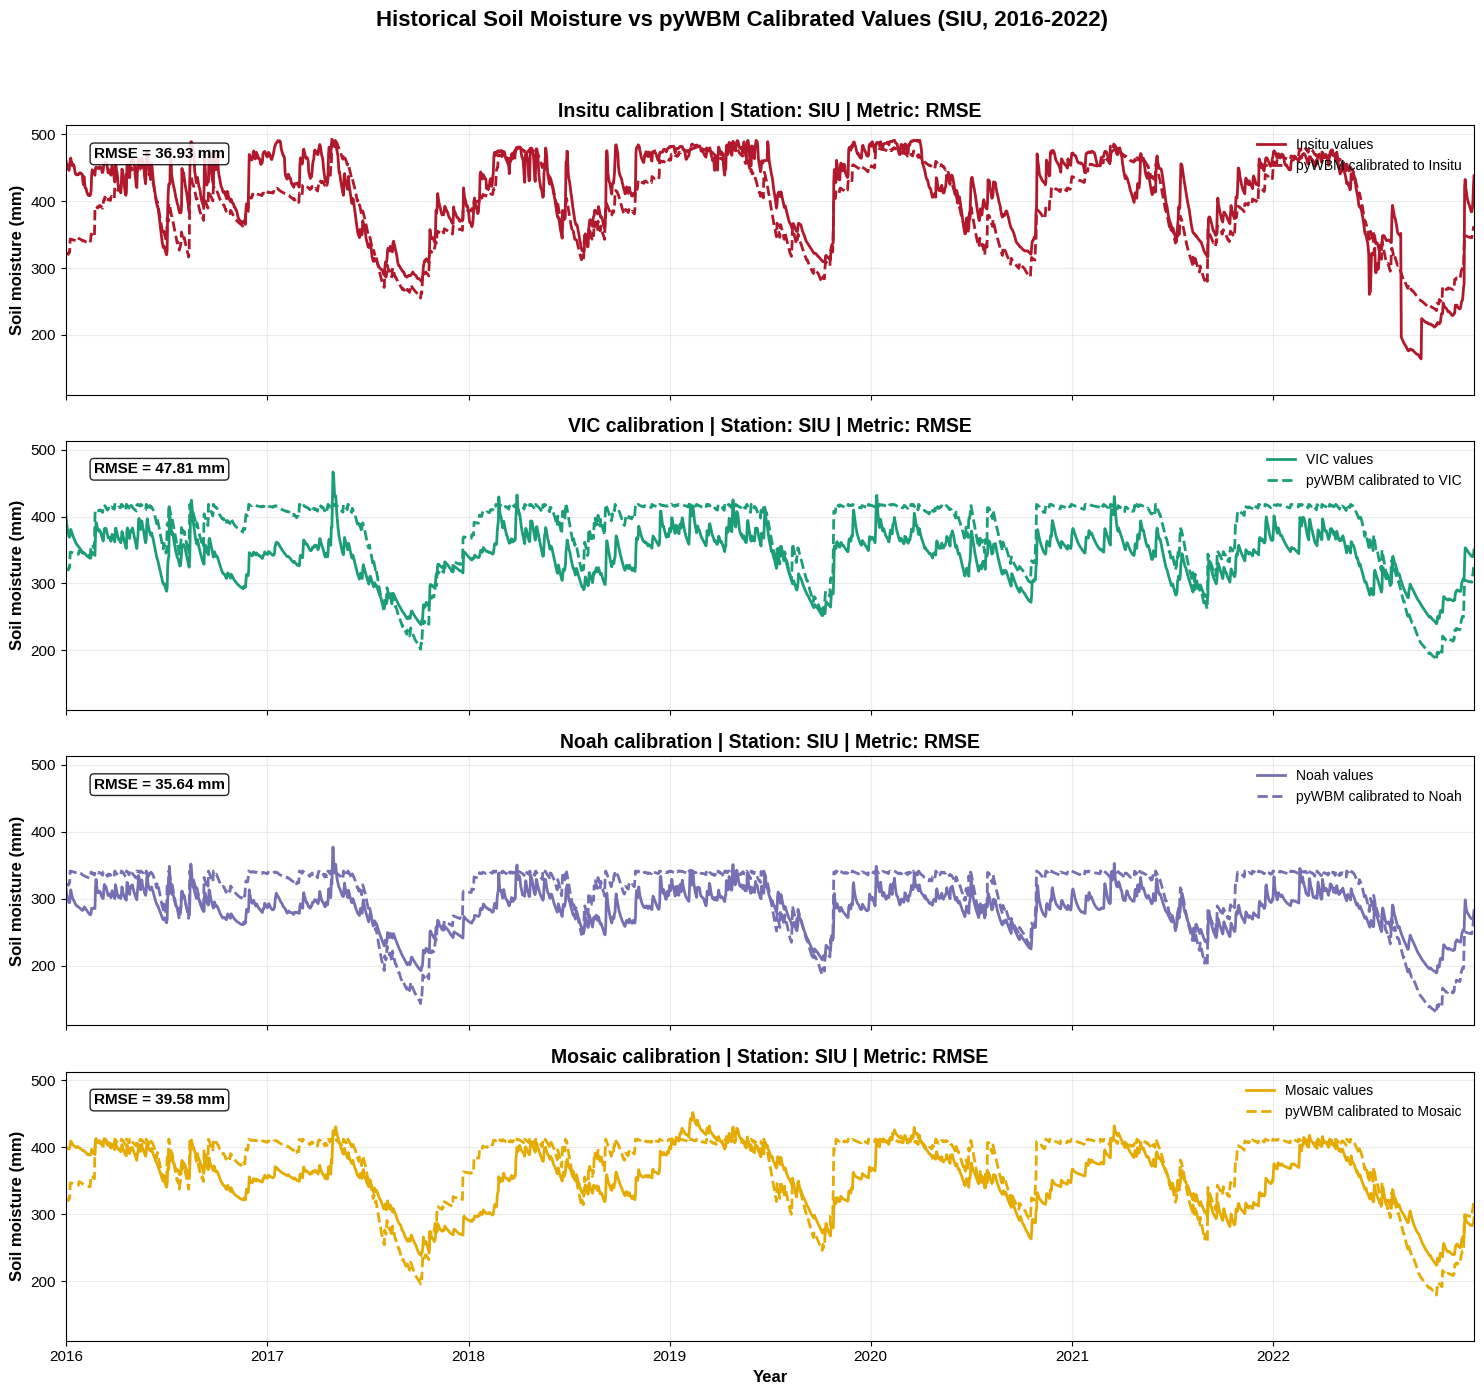

In [9]:
#!/usr/bin/env python3


# ============================================================
# GLOBAL FONT SETTINGS
# ============================================================
mpl.rcParams.update({
    "font.family": "Liberation Sans",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "figure.titlesize": 16,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ============================================================
# PATHS
# ============================================================

os.makedirs(PLOT_DIR, exist_ok=True)

METRIC_OUTDIRS = {
    "kge":         f"{CAL_DIR}/calibration_outputs_kge_gridmet",
    "kgeprime":    f"{CAL_DIR}/calibration_outputs_kgeprime_gridmet",
    "rmse":        f"{CAL_DIR}/calibration_outputs_rmse_gridmet",
    "outer50rmse": f"{CAL_DIR}/calibration_outputs_outer50rmse_gridmet",
}

# ============================================================
# USER SETTINGS
# ============================================================
REP_STATION = "SIU"
PLOT_METRIC = "rmse"

# Excludes SMAP, bias-corrected data, and full-term in-situ
plot_groups = ["ins7", "vic_raw", "noah_raw", "mosaic_raw"]

PLOT_GROUP_LABELS = {
    "ins7": "Insitu",
    "vic_raw": "VIC",
    "noah_raw": "Noah",
    "mosaic_raw": "Mosaic",
}

SOURCE_LABELS = {
    "ins7": "Insitu",
    "vic_raw": "VIC",
    "noah_raw": "Noah",
    "mosaic_raw": "Mosaic",
}

COLORS = {
    "ins7": "#B2182B",
    "vic_raw": "#1B9E77",
    "noah_raw": "#7570B3",
    "mosaic_raw": "#E6AB02",
}

START_DATE = "2016-01-01"
END_DATE = "2022-12-31"

# ============================================================
# HELPERS
# ============================================================
def scenario_group(attrs):
    src = str(attrs.get("data_source", "")).strip().lower()
    startdate = str(attrs.get("startdate", "")).strip()

    try:
        use_bc = int(attrs.get("use_bias_corrected", 0))
    except Exception:
        use_bc = 0

    if src == "insitu":
        if startdate == "2016-01-01":
            return "ins7"
        return "ins20"

    if src in ["smap", "vic", "mosaic", "noah"]:
        return f"{src}_{'bc' if use_bc == 1 else 'raw'}"

    return None


def time_to_pandas(time_values):
    out = []

    for tt in time_values:
        if hasattr(tt, "year") and hasattr(tt, "month") and hasattr(tt, "day"):
            out.append(pd.Timestamp(tt.year, tt.month, tt.day))
        else:
            out.append(pd.Timestamp(tt))

    return pd.DatetimeIndex(out)


def calc_rmse(pred, obs):
    pred = np.asarray(pred, dtype=float)
    obs = np.asarray(obs, dtype=float)

    mask = np.isfinite(pred) & np.isfinite(obs)

    if mask.sum() == 0:
        return np.nan

    return np.sqrt(np.mean((pred[mask] - obs[mask]) ** 2))


# ============================================================
# LOAD TARGET AND pyWBM VALUES
# ============================================================
rows = []

out_dir = METRIC_OUTDIRS[PLOT_METRIC]
files = sorted(glob.glob(os.path.join(out_dir, "scenario_*.nc")))

for f in files:
    ds = None

    try:
        ds = xr.open_dataset(f)

        grp = scenario_group(ds.attrs)

        if grp not in plot_groups:
            continue

        station = str(ds.attrs.get("station", "")).strip()

        if station != REP_STATION:
            continue

        if "target_sm" not in ds or "pred_sm_best" not in ds:
            continue

        rows.append({
            "metric": PLOT_METRIC,
            "station": station,
            "group": grp,
            "obs": np.asarray(ds["target_sm"].values, dtype=float),
            "pred": np.asarray(ds["pred_sm_best"].values, dtype=float),
            "time": ds["time"].values,
            "file": f,
        })

    except Exception as e:
        print(f"Skipping {os.path.basename(f)} because of error: {e}")

    finally:
        if ds is not None:
            ds.close()

df_scatter = pd.DataFrame(rows)

if df_scatter.empty:
    raise ValueError(
        f"No data found for station={REP_STATION}, "
        f"metric={PLOT_METRIC}, groups={plot_groups}"
    )

print("\nLoaded records:")
print(df_scatter[["station", "group", "metric", "file"]])

# ============================================================
# COMMON Y-AXIS LIMITS FOR 2016-2022
# ============================================================
all_vals = []

for grp in plot_groups:
    sub = df_scatter[
        (df_scatter["group"] == grp) &
        (df_scatter["station"] == REP_STATION) &
        (df_scatter["metric"] == PLOT_METRIC)
    ]

    if sub.empty:
        continue

    row = sub.iloc[0]

    t = time_to_pandas(row["time"])
    obs = np.asarray(row["obs"], dtype=float)
    pred = np.asarray(row["pred"], dtype=float)

    mask = (t >= pd.Timestamp(START_DATE)) & (t <= pd.Timestamp(END_DATE))

    all_vals.append(obs[mask])
    all_vals.append(pred[mask])

all_vals = np.concatenate(all_vals)
all_vals = all_vals[np.isfinite(all_vals)]

if all_vals.size == 0:
    raise ValueError("No finite values found in selected 2016-2022 plotting window.")

ymin = np.nanmin(all_vals)
ymax = np.nanmax(all_vals)
ypad = 0.05 * (ymax - ymin) if ymax > ymin else 1.0

# ============================================================
# PLOT
# ============================================================
fig, axes = plt.subplots(
    len(plot_groups),
    1,
    figsize=(15, 14),
    sharex=True,
    sharey=True
)

if len(plot_groups) == 1:
    axes = [axes]

for ax, grp in zip(axes, plot_groups):
    sub = df_scatter[
        (df_scatter["group"] == grp) &
        (df_scatter["station"] == REP_STATION) &
        (df_scatter["metric"] == PLOT_METRIC)
    ]

    if sub.empty:
        ax.text(
            0.5,
            0.5,
            f"No data for {REP_STATION} in {PLOT_GROUP_LABELS.get(grp, grp)}",
            transform=ax.transAxes,
            ha="center",
            va="center"
        )
        ax.set_axis_off()
        continue

    row = sub.iloc[0]

    t = time_to_pandas(row["time"])
    obs = np.asarray(row["obs"], dtype=float)
    pred = np.asarray(row["pred"], dtype=float)

    mask = (t >= pd.Timestamp(START_DATE)) & (t <= pd.Timestamp(END_DATE))

    t_plot = t[mask]
    obs_plot = obs[mask]
    pred_plot = pred[mask]

    rmse_val = calc_rmse(pred_plot, obs_plot)

    ax.plot(
        t_plot,
        obs_plot,
        color=COLORS[grp],
        linewidth=2.0,
        linestyle="-",
        label=f"{SOURCE_LABELS[grp]} values"
    )

    ax.plot(
        t_plot,
        pred_plot,
        color=COLORS[grp],
        linewidth=2.0,
        linestyle="--",
        label=f"pyWBM calibrated to {SOURCE_LABELS[grp]}"
    )

    ax.text(
        0.02,
        0.92,
        f"RMSE = {rmse_val:.2f} mm",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=11,
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            edgecolor="black",
            alpha=0.85,
            boxstyle="round,pad=0.25"
        )
    )

    ax.set_title(
        f"{PLOT_GROUP_LABELS[grp]} calibration | "
        f"Station: {REP_STATION} | Metric: {PLOT_METRIC.upper()}",
        fontweight="bold"
    )

    ax.set_ylabel("Soil moisture (mm)")
    ax.set_ylim(ymin - ypad, ymax + ypad)
    ax.set_xlim(pd.Timestamp(START_DATE), pd.Timestamp(END_DATE))
    ax.grid(alpha=0.25)

    ax.legend(
        frameon=False,
        loc="upper right",
        fontsize=10
    )

axes[-1].set_xlabel("Year")

fig.suptitle(
    f"Historical Soil Moisture vs pyWBM Calibrated Values "
    f"({REP_STATION}, {START_DATE[:4]}-{END_DATE[:4]})",
    fontsize=16,
    fontweight="bold",
    y=0.995
)

plt.tight_layout(rect=[0, 0, 1, 0.97])

save_name = os.path.join(
    PLOT_DIR,
    f"FigA1_time_series_{REP_STATION}_{PLOT_METRIC}_2016_2022_no_smap_raw_sources.png"
)

plt.savefig(
    save_name,
    dpi=1200,
    bbox_inches="tight",
    facecolor="white"
)

print("Saved:", save_name)

plt.show()

### Calibration Loss Plot (Fig 3.3)

optimized_metric  group     
rmse              insitu        17
                  smap_raw      17
                  vic_raw       17
                  noah_raw      17
                  mosaic_raw    17
outer50rmse       insitu        17
                  smap_raw      17
                  vic_raw       17
                  noah_raw      17
                  mosaic_raw    17
kge               insitu        17
                  smap_raw      17
                  vic_raw       17
                  noah_raw      17
                  mosaic_raw    17
kgeprime          insitu        17
                  smap_raw      17
                  vic_raw       17
                  noah_raw      17
                  mosaic_raw    17
dtype: int64


/tmp/ipykernel_3600223/4190608465.py:370: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.04, 1, 0.94])


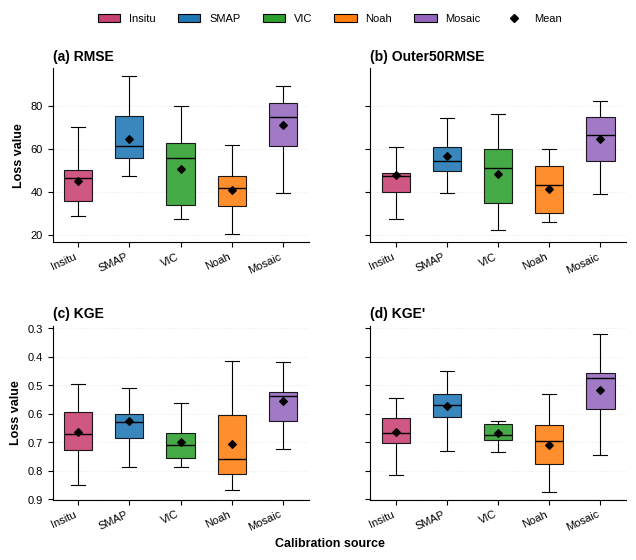

In [13]:
os.makedirs(PLOT_DIR, exist_ok=True)

METRIC_OUTDIRS = {
    "kge":         f"{CAL_DIR}/calibration_outputs_kge_gridmet",
    "kgeprime":    f"{CAL_DIR}/calibration_outputs_kgeprime_gridmet",
    "rmse":        f"{CAL_DIR}/calibration_outputs_rmse_gridmet",
    "outer50rmse": f"{CAL_DIR}/calibration_outputs_outer50rmse_gridmet",
}

metric_panel_order = ["rmse", "outer50rmse", "kge", "kgeprime"]

plt.rcParams.update({
    "font.family": "Liberation Sans",
    "axes.titlesize": 10,
    "axes.titleweight": "bold",
    "axes.labelsize": 9,
    "axes.labelweight": "bold",
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "legend.title_fontsize": 8,
    "axes.linewidth": 0.8,
    "axes.edgecolor": "black",
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

COLORS = {
    "insitu": "#C94072",
    "smap_raw": "#1f77b4",
    "vic_raw": "#2ca02c",
    "noah_raw": "#ff7f0e",
    "mosaic_raw": "#9467bd",
}

GROUP_LABELS = {
    "insitu": "Insitu",
    "smap_raw": "SMAP",
    "vic_raw": "VIC",
    "noah_raw": "Noah",
    "mosaic_raw": "Mosaic",
}

group_order = [
    "insitu",
    "smap_raw",
    "vic_raw",
    "noah_raw",
    "mosaic_raw",
]

metric_titles = {
    "kge": "KGE",
    "kgeprime": "KGE'",
    "rmse": "RMSE",
    "outer50rmse": "Outer50RMSE",
}

EXCLUDE_STATIONS = set()

def scenario_group(attrs):
    src = str(attrs.get("data_source", "")).strip().lower()
    startdate = str(attrs.get("startdate", "")).strip()

    try:
        use_bc = int(attrs.get("use_bias_corrected", 0))
    except Exception:
        use_bc = 0

    if src == "insitu":
        return "insitu"

    if src in ["smap", "vic", "mosaic", "noah"]:
        return f"{src}_{'bc' if use_bc == 1 else 'raw'}"

    return None

def load_metric_folder(out_dir, optimized_metric):
    files = sorted(glob.glob(os.path.join(out_dir, "scenario_*.nc")))
    rows = []

    if len(files) == 0:
        print(f"No scenario files found in: {out_dir}")
        return pd.DataFrame()

    for f in files:
        ds = None

        try:
            ds = xr.open_dataset(f)

            grp = scenario_group(ds.attrs)

            if grp is None:
                continue

            # remove all bias-corrected gridded products
            if grp.endswith("_bc"):
                continue

            if grp not in group_order:
                continue

            station = str(ds.attrs.get("station", "")).strip()

            if station in EXCLUDE_STATIONS:
                continue

            pred_loss_best = np.asarray(ds["pred_loss_best"].values, dtype=float)
            train_loss_best = np.asarray(ds["train_loss_best"].values, dtype=float)
            reg_loss_best = np.asarray(ds["reg_loss_best"].values, dtype=float)

            final_pred_loss = (
                pred_loss_best[np.isfinite(pred_loss_best)][-1]
                if np.isfinite(pred_loss_best).any()
                else np.nan
            )

            final_train_loss = (
                train_loss_best[np.isfinite(train_loss_best)][-1]
                if np.isfinite(train_loss_best).any()
                else np.nan
            )

            final_reg_loss = (
                reg_loss_best[np.isfinite(reg_loss_best)][-1]
                if np.isfinite(reg_loss_best).any()
                else np.nan
            )

            try:
                use_bc = int(ds.attrs.get("use_bias_corrected", 0))
            except Exception:
                use_bc = 0

            rows.append({
                "file": f,
                "station": station,
                "group": grp,
                "group_label": GROUP_LABELS[grp],
                "optimized_metric": optimized_metric,
                "data_source": str(ds.attrs.get("data_source", "")),
                "startdate": str(ds.attrs.get("startdate", "")),
                "enddate": str(ds.attrs.get("enddate", "")),
                "use_bias_corrected": use_bc,
                "final_pred_loss": final_pred_loss,
                "final_train_loss": final_train_loss,
                "final_reg_loss": final_reg_loss,
            })

        except Exception as e:
            print(f"Skipping {os.path.basename(f)} from {optimized_metric} because of error: {e}")

        finally:
            if ds is not None:
                ds.close()

    return pd.DataFrame(rows)

def load_all_metric_outputs(metric_outdirs):
    dfs = []

    for metric_name, out_dir in metric_outdirs.items():
        df_one = load_metric_folder(
            out_dir=out_dir,
            optimized_metric=metric_name,
        )

        if not df_one.empty:
            dfs.append(df_one)

    if len(dfs) == 0:
        raise ValueError("No valid scenario files loaded from metric folders.")

    df_all = pd.concat(dfs, ignore_index=True)

    df_all = df_all.drop_duplicates(
        subset=["station", "group", "optimized_metric"],
        keep="first"
    ).copy()

    df_all["group"] = pd.Categorical(
        df_all["group"],
        categories=group_order,
        ordered=True,
    )

    df_all["optimized_metric"] = pd.Categorical(
        df_all["optimized_metric"],
        categories=metric_panel_order,
        ordered=True,
    )

    df_all = df_all.sort_values(
        ["optimized_metric", "group", "station"]
    ).reset_index(drop=True)

    return df_all

def plot_metric_loss_boxplots(df, save_path=None):
    fig = plt.figure(figsize=(7.4, 5.6))

    gs = fig.add_gridspec(
        2,
        2,
        hspace=0.48,
        wspace=0.24,
    )

    ax_rmse = fig.add_subplot(gs[0, 0])
    ax_outer = fig.add_subplot(gs[0, 1], sharey=ax_rmse)
    ax_kge = fig.add_subplot(gs[1, 0])
    ax_kgeprime = fig.add_subplot(gs[1, 1], sharey=ax_kge)

    axis_map = {
        "rmse": ax_rmse,
        "outer50rmse": ax_outer,
        "kge": ax_kge,
        "kgeprime": ax_kgeprime,
    }

    panel_labels = {
        "rmse": "(a)",
        "outer50rmse": "(b)",
        "kge": "(c)",
        "kgeprime": "(d)",
    }

    def draw_metric_panel(ax, metric):
        sub = df[df["optimized_metric"] == metric].copy()

        available_groups = [
            g for g in group_order
            if g in sub["group"].astype(str).unique()
        ]

        data = []
        colors = []
        labels = []

        for g in available_groups:
            vals = sub.loc[
                sub["group"].astype(str) == g,
                "final_pred_loss"
            ].dropna().values

            if len(vals) > 0:
                data.append(vals)
                colors.append(COLORS[g])
                labels.append(GROUP_LABELS[g])

        if len(data) == 0:
            ax.set_title(f"{panel_labels[metric]} {metric_titles[metric]}", loc="left")
            ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
            ax.set_xticks([])
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            return

        bp = ax.boxplot(
            data,
            patch_artist=True,
            widths=0.55,
            showfliers=False,
            medianprops=dict(color="black", linewidth=1.0),
            whiskerprops=dict(color="black", linewidth=0.8),
            capprops=dict(color="black", linewidth=0.8),
            boxprops=dict(edgecolor="black", linewidth=0.8),
        )

        for patch, c in zip(bp["boxes"], colors):
            patch.set_facecolor(c)
            patch.set_alpha(0.88)

        means = [np.nanmean(d) for d in data]

        ax.scatter(
            np.arange(1, len(means) + 1),
            means,
            marker="D",
            s=15,
            color="black",
            zorder=3,
        )

        ax.set_title(
            f"{panel_labels[metric]} {metric_titles[metric]}",
            loc="left",
            pad=6,
            fontweight="bold"
        )

        ax.set_xticks(np.arange(1, len(labels) + 1))
        ax.set_xticklabels(labels, rotation=25, ha="right")
        ax.tick_params(axis="x", pad=3)

        ax.grid(
            axis="y",
            linestyle="--",
            linewidth=0.4,
            alpha=0.25,
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    for metric, ax in axis_map.items():
        draw_metric_panel(ax, metric)

    # Reverse KGE/KGE' axes because higher skill is better
    kge_vals = df.loc[
        df["optimized_metric"].isin(["kge", "kgeprime"]),
        "final_pred_loss"
    ].dropna().values

    if len(kge_vals) > 0:
        kge_min = np.nanmin(kge_vals)
        kge_max = np.nanmax(kge_vals)
        pad = 0.05 * (kge_max - kge_min) if kge_max > kge_min else 0.05

        ax_kge.set_ylim(kge_max + pad, kge_min - pad)
        ax_kgeprime.set_ylim(kge_max + pad, kge_min - pad)

    ax_rmse.set_ylabel("Loss value")
    ax_kge.set_ylabel("Loss value")

    plt.setp(ax_outer.get_yticklabels(), visible=False)
    plt.setp(ax_kgeprime.get_yticklabels(), visible=False)

    legend_handles = [
        Patch(
            facecolor=COLORS[g],
            edgecolor="black",
            linewidth=0.8,
            label=GROUP_LABELS[g],
        )
        for g in group_order
    ] + [
        Line2D(
            [0],
            [0],
            marker="D",
            color="black",
            linestyle="None",
            markersize=4,
            label="Mean",
        )
    ]

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        ncol=6,
        frameon=False,
        bbox_to_anchor=(0.5, 0.995),
        fontsize=8,
    )

    fig.supxlabel(
        "Calibration source",
        y=0.02,
        fontsize=9,
        fontweight="bold",
    )

    plt.tight_layout(rect=[0, 0.04, 1, 0.94])

    if save_path is not None:
        fig.savefig(save_path, dpi=600, bbox_inches="tight")
        #fig.savefig(save_path.replace(".png", ".pdf"), bbox_inches="tight")

    plt.show()
    plt.close(fig)

df_all = load_all_metric_outputs(METRIC_OUTDIRS)

mask_kge = df_all["optimized_metric"].isin(["kge", "kgeprime"])
df_all.loc[mask_kge, "final_pred_loss"] = -df_all.loc[mask_kge, "final_pred_loss"]

print(df_all.groupby(["optimized_metric", "group"], observed=False).size())

plot_metric_loss_boxplots(
    df_all,
    save_path=os.path.join(PLOT_DIR, "Fig33_Calibration_loss_boxplot_journal_raw_products_only.png"),
)

### Parameter Estimation (Fig A.2)

Available groups:
['ins20', 'ins7', 'mosaic_bc', 'mosaic_raw', 'noah_bc', 'noah_raw', 'smap_bc', 'smap_raw', 'vic_bc', 'vic_raw']
Saved: /data/keeling/a/tahsina2/Alam_et_al_2026/plots/FigA2_parameter_boxplots_awcap_wiltingp_smap_noah_vic_mosaic_insitu.png


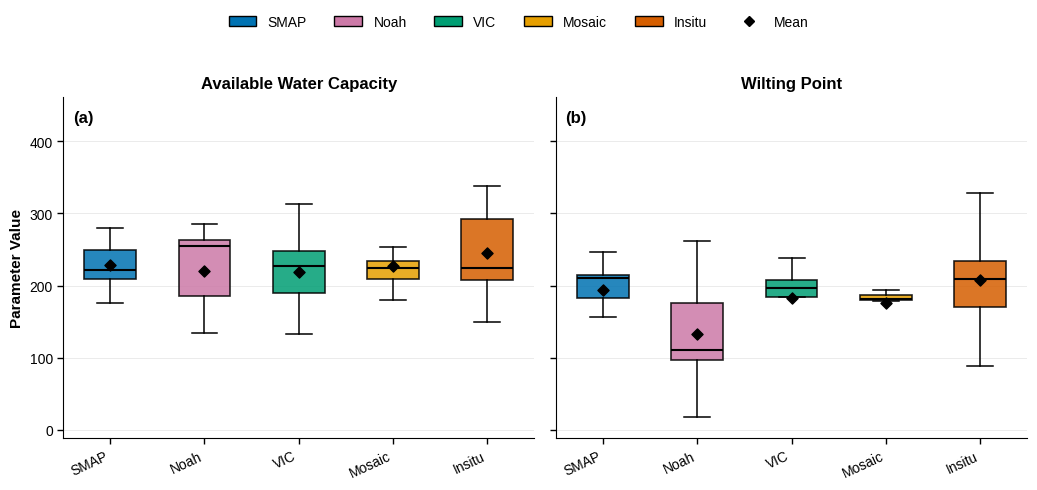

In [14]:
#!/usr/bin/env python3



# ============================================================
# GLOBAL FONT SETTINGS
# ============================================================
mpl.rcParams.update({
    "font.family": "Liberation Sans",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 14,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ============================================================
# PATHS
# ============================================================

os.makedirs(PLOT_DIR, exist_ok=True)

param_nc = (
    "/data/keeling/a/tahsina2/Alam_et_al_2026/data/Calibration/AllStations/"
    "calibrated_effective_params_initial_and_final_all_metrics.nc"
)

save_path = os.path.join(
    PLOT_DIR,
    "FigA2_parameter_boxplots_awcap_wiltingp_smap_noah_vic_mosaic_insitu.png"
)

# ============================================================
# SETTINGS
# ============================================================
param_order = ["awCap", "wiltingp"]

parameter_full = {
    "awCap": "Available Water Capacity",
    "wiltingp": "Wilting Point",
}

# Raw products only + 7-year in-situ only
group_order = ["smap_raw", "noah_raw", "vic_raw", "mosaic_raw", "ins7"]

GROUP_LABELS = {
    "smap_raw": "SMAP",
    "noah_raw": "Noah",
    "vic_raw": "VIC",
    "mosaic_raw": "Mosaic",
    "ins7": "Insitu",
}

# Color-blind friendly Okabe-Ito palette
COLORS = {
    "smap_raw": "#0072B2",
    "noah_raw": "#CC79A7",
    "vic_raw": "#009E73",
    "mosaic_raw": "#E69F00",
    "ins7": "#D55E00",
}

# ============================================================
# LOAD DATA
# ============================================================
ds_param = xr.open_dataset(param_nc)
df_param = ds_param.to_dataframe().reset_index()
ds_param.close()

print("Available groups:")
print(sorted(df_param["group"].astype(str).unique()))

# Keep only desired groups
df_param = df_param[df_param["group"].astype(str).isin(group_order)].copy()

if df_param.empty:
    raise ValueError(
        "No matching groups found. Check group names in the printed list above."
    )

# ============================================================
# PLOT FUNCTION
# ============================================================
def plot_awcap_wiltingp_boxplots(df, save_path=None):

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(10.5, 4.8),
        sharey=True
    )

    available_groups = [
        g for g in group_order
        if g in df["group"].astype(str).unique()
    ]

    all_vals_common = []

    for p in param_order:
        col = f"{p}_final"

        if col not in df.columns:
            continue

        vals = df.loc[
            df["group"].astype(str).isin(available_groups),
            col
        ].dropna().values

        if len(vals) > 0:
            all_vals_common.append(vals)

    if not all_vals_common:
        raise ValueError("No valid parameter values found for awCap or wiltingp.")

    all_vals_common = np.concatenate(all_vals_common)
    ymin = np.nanmin(all_vals_common)
    ymax = np.nanmax(all_vals_common)
    ypad = 0.07 * (ymax - ymin) if ymax > ymin else 1.0

    panel_labels = ["(a)", "(b)"]

    for i, (ax, p) in enumerate(zip(axes, param_order)):

        data = []
        colors = []
        labels = []

        col = f"{p}_final"

        if col not in df.columns:
            ax.set_visible(False)
            continue

        for g in available_groups:
            vals = df.loc[
                df["group"].astype(str) == g,
                col
            ].dropna().values

            if len(vals) > 0:
                data.append(vals)
                colors.append(COLORS[g])
                labels.append(GROUP_LABELS[g])

        if len(data) == 0:
            ax.set_visible(False)
            continue

        bp = ax.boxplot(
            data,
            patch_artist=True,
            widths=0.55,
            showfliers=False,
            medianprops=dict(color="black", linewidth=1.5),
            whiskerprops=dict(color="black", linewidth=1.1),
            capprops=dict(color="black", linewidth=1.1),
            boxprops=dict(edgecolor="black", linewidth=1.2)
        )

        for patch, c in zip(bp["boxes"], colors):
            patch.set_facecolor(c)
            patch.set_alpha(0.85)

        means = [np.nanmean(d) for d in data]

        ax.scatter(
            np.arange(1, len(means) + 1),
            means,
            marker="D",
            s=32,
            color="black",
            zorder=4
        )

        ax.text(
            0.02,
            0.96,
            panel_labels[i],
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=12,
            fontweight="bold"
        )

        ax.set_title(parameter_full[p], fontweight="bold")
        ax.set_xticks(np.arange(1, len(labels) + 1))
        ax.set_xticklabels(labels, rotation=25, ha="right")

        if i == 0:
            ax.set_ylabel("Parameter Value")

        ax.set_ylim(ymin - ypad, ymax + ypad)
        ax.grid(axis="y", alpha=0.25, linewidth=0.7)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.tick_params(axis="both", width=1.0, length=4)

    legend_handles = [
        Patch(facecolor=COLORS[g], edgecolor="black", label=GROUP_LABELS[g])
        for g in available_groups
    ] + [
        Line2D(
            [0], [0],
            marker="D",
            color="black",
            linestyle="None",
            markersize=5.5,
            label="Mean"
        )
    ]

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        ncol=6,
        frameon=False,
        bbox_to_anchor=(0.5, 1.03)
    )

    fig.tight_layout(rect=[0, 0, 1, 0.91])

    if save_path is not None:
        fig.savefig(
            save_path,
            dpi=1200,
            bbox_inches="tight",
            facecolor="white"
        )

        # fig.savefig(
        #     save_path.replace(".png", ".pdf"),
        #     dpi=1200,
        #     bbox_inches="tight",
        #     facecolor="white"
        # )

        print("Saved:", save_path)
        #print("Saved:", save_path.replace(".png", ".pdf"))

    plt.show()
    plt.close(fig)


plot_awcap_wiltingp_boxplots(
    df_param,
    save_path=save_path
)

### Calibration Loss Table (Table A.2)

In [16]:
#!/usr/bin/env python3

# ============================================================
# PATHS
# ============================================================

OUT_DIR = TABLE_DIR
os.makedirs(OUT_DIR, exist_ok=True)

METRIC_OUTDIRS = {
    "kge":         f"{CAL_DIR}/calibration_outputs_kge_gridmet",
    "kgeprime":    f"{CAL_DIR}/calibration_outputs_kgeprime_gridmet",
    "rmse":        f"{CAL_DIR}/calibration_outputs_rmse_gridmet",
    "outer50rmse": f"{CAL_DIR}/calibration_outputs_outer50rmse_gridmet",
}

# ============================================================
# SETTINGS
# ============================================================
KEEP_GROUPS = [
    "smap_raw",
    "vic_raw",
    "noah_raw",
    "mosaic_raw",
    "ins7",
]

# ============================================================
# HELPERS
# ============================================================
def scenario_group(attrs):
    src = str(attrs.get("data_source", "")).strip().lower()
    startdate = str(attrs.get("startdate", "")).strip()

    try:
        use_bc = int(attrs.get("use_bias_corrected", 0))
    except Exception:
        use_bc = 0

    if src == "insitu":
        if startdate == "2016-01-01":
            return "ins7"
        return "ins20"

    if src in ["smap", "vic", "mosaic", "noah"]:
        return f"{src}_{'bc' if use_bc == 1 else 'raw'}"

    return src if src else None


def source_label(group):
    labels = {
        "smap_raw": "SMAP raw",
        "vic_raw": "VIC raw",
        "noah_raw": "NOAH raw",
        "mosaic_raw": "MOSAIC raw",
        "ins7": "In-situ 7y",
    }
    return labels.get(group, group)


def get_final_loss(ds):
    """
    Extract final calibration loss from actual pyWBM output variables.
    Preference:
    1. train_loss_best final epoch
    2. pred_loss_best final epoch
    3. reg_loss_best final epoch
    """

    var_candidates = [
        "train_loss_best",
        "pred_loss_best",
        "reg_loss_best",
        "final_loss",
        "best_loss",
        "loss_final",
        "train_loss",
        "loss",
        "objective",
        "loss_history",
    ]

    attr_candidates = [
        "final_loss",
        "best_loss",
        "loss_final",
        "train_loss_final",
        "objective_final",
    ]

    for name in attr_candidates:
        if name in ds.attrs:
            try:
                return float(ds.attrs[name]), f"attr:{name}"
            except Exception:
                pass

    for name in var_candidates:
        if name in ds:
            vals = np.asarray(ds[name].values, dtype=float).ravel()
            vals = vals[np.isfinite(vals)]

            if vals.size > 0:
                return float(vals[-1]), f"var:{name}"

    return np.nan, "not_found"


# ============================================================
# EXTRACT FINAL LOSS TABLE
# ============================================================
rows = []

for metric, out_dir in METRIC_OUTDIRS.items():
    files = sorted(glob.glob(os.path.join(out_dir, "scenario_*.nc")))

    print(f"{metric}: found {len(files)} files")

    for f in files:
        ds = None

        try:
            ds = xr.open_dataset(f)

            station = str(ds.attrs.get("station", "")).strip()
            group = scenario_group(ds.attrs)

            # Exclude bias-corrected data and full-period in-situ
            if group not in KEEP_GROUPS:
                ds.close()
                continue

            final_loss, loss_source = get_final_loss(ds)

            rows.append({
                "station": station,
                "metric": metric,
                "group": group,
                "data_source": source_label(group),
                "final_loss": final_loss,
                "loss_source": loss_source,
                "file": os.path.basename(f),
            })

        except Exception as e:
            print(f"Skipping {os.path.basename(f)} because of error: {e}")

        finally:
            if ds is not None:
                ds.close()

loss_df = pd.DataFrame(rows)

if loss_df.empty:
    raise ValueError(
        "No calibration files matched KEEP_GROUPS. "
        "Check whether raw VIC/NOAH/MOSAIC/SMAP and ins7 files exist."
    )

# ============================================================
# CLEAN AND SORT
# ============================================================
source_order = {
    "SMAP raw": 1,
    "VIC raw": 2,
    "NOAH raw": 3,
    "MOSAIC raw": 4,
    "In-situ 7y": 5,
}

loss_df["source_order"] = loss_df["data_source"].map(source_order)

loss_df = loss_df.sort_values(
    ["station", "source_order", "metric"]
).reset_index(drop=True)



# Wide-format table
wide_df = loss_df.pivot_table(
    index=["station", "data_source"],
    columns="metric",
    values="final_loss",
    aggfunc="first"
).reset_index()

wide_df["source_order"] = wide_df["data_source"].map(source_order)

wide_df = wide_df.sort_values(
    ["station", "source_order"]
).drop(columns=["source_order"]).reset_index(drop=True)

wide_df.columns.name = None

wide_csv = os.path.join(
    OUT_DIR,
    "TableA2_final_loss_raw_sources_insitu7_metrics_stations_wide.csv"
)

wide_df.to_csv(wide_csv, index=False)


# ============================================================
# SUPPLEMENTARY TABLE
# ============================================================

metric_labels = {
    "kge": "KGE",
    "kgeprime": "KGE\u2032",
    "rmse": "RMSE",
    "outer50rmse": "Outer50RMSE",
}

source_labels_clean = {
    "SMAP raw": "SMAP",
    "VIC raw": "VIC",
    "NOAH raw": "Noah",
    "MOSAIC raw": "Mosaic",
    "In-situ 7y": "In-situ",
}

source_order = {
    "SMAP": 1,
    "VIC": 2,
    "Noah": 3,
    "Mosaic": 4,
    "In-situ": 5,
}

supp_df = wide_df.copy()

# Clean source names
supp_df["data_source"] = supp_df["data_source"].map(source_labels_clean)

# Rename columns
supp_df = supp_df.rename(columns={
    "station": "Station",
    "data_source": "Calibration dataset",
    **metric_labels
})

# Keep preferred column order
ordered_cols = [
    "Station",
    "Calibration dataset",
    "KGE",
    "KGE\u2032",
    "RMSE",
    "Outer50RMSE",
]

supp_df = supp_df[[c for c in ordered_cols if c in supp_df.columns]]

# Sort
supp_df["source_order"] = supp_df["Calibration dataset"].map(source_order)
supp_df = supp_df.sort_values(
    ["Station", "source_order"]
).drop(columns=["source_order"]).reset_index(drop=True)

# Round numeric columns
for col in ["KGE", "KGE\u2032", "RMSE", "Outer50RMSE"]:
    if col in supp_df.columns:
        supp_df[col] = supp_df[col].round(3)

# Save CSV
supp_csv = os.path.join(
    OUT_DIR,
    "Table_A2_final_calibration_loss_raw_sources_insitu7.csv"
)

supp_df.to_csv(supp_csv, index=False)


print("\nsupplementary table:")
print(supp_df)

print("\nSaved:")
print(supp_csv)


kge: found 170 files
kgeprime: found 170 files
rmse: found 170 files
outer50rmse: found 170 files

Journal-ready supplementary table:
   Station Calibration dataset    KGE   KGE′    RMSE  Outer50RMSE
0      BRW                SMAP -0.638 -0.570  63.764       53.224
1      BRW                 VIC -0.759 -0.687  68.687       65.557
2      BRW                Noah -0.803 -0.810  45.112       42.511
3      BRW              Mosaic -0.537 -0.475  72.777       70.649
4      BRW             In-situ -0.581 -0.569  40.832       48.841
..     ...                 ...    ...    ...     ...          ...
80     STE                SMAP -0.601 -0.518  75.499       64.082
81     STE                 VIC -0.623 -0.546  59.976       54.623
82     STE                Noah -0.728 -0.513  51.518       59.854
83     STE              Mosaic -0.536 -0.450  81.945       66.439
84     STE             In-situ -0.394 -0.367  51.042       51.141

[85 rows x 6 columns]

Saved:
/data/keeling/a/tahsina2/Alam_et_al_2026/ta